In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
df = pd.read_csv("car_price_prediction_.csv")

print(df)

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:\n", missing_values)
df.info()



      Car ID   Brand  Year  Engine Size Fuel Type Transmission  Mileage Condition     Price     Model
0          1   Tesla  2016          2.3    Petrol       Manual   114832       New  26613.92   Model X
1          2     BMW  2018          4.4  Electric       Manual   143190      Used  14679.61  5 Series
2          3    Audi  2013          4.5  Electric       Manual   181601       New  44402.61        A4
3          4   Tesla  2011          4.1    Diesel    Automatic    68682       New  86374.33   Model Y
4          5    Ford  2009          2.6    Diesel       Manual   223009  Like New  73577.10   Mustang
...      ...     ...   ...          ...       ...          ...      ...       ...       ...       ...
2495    2496    Audi  2020          2.4    Petrol    Automatic    22650  Like New  61384.10        Q5
2496    2497    Audi  2001          5.7    Hybrid       Manual    77701  Like New  24710.35        A3
2497    2498    Ford  2021          1.1    Hybrid       Manual   272827  Like New 

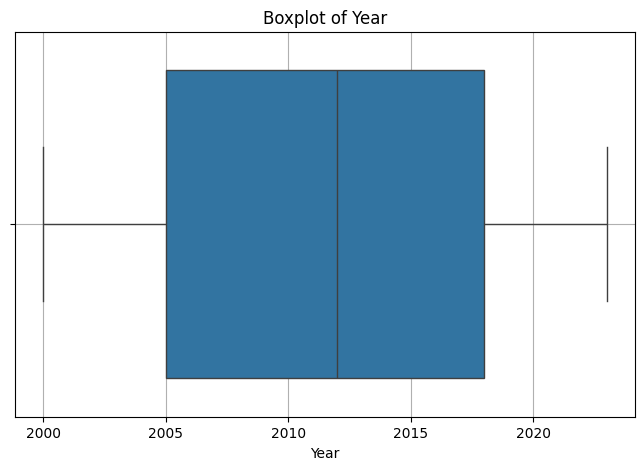

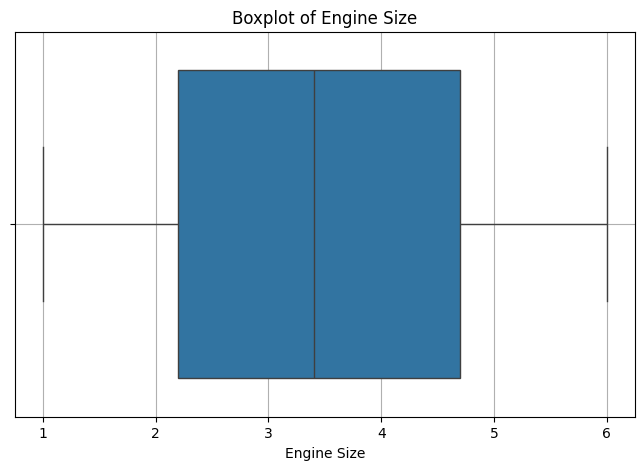

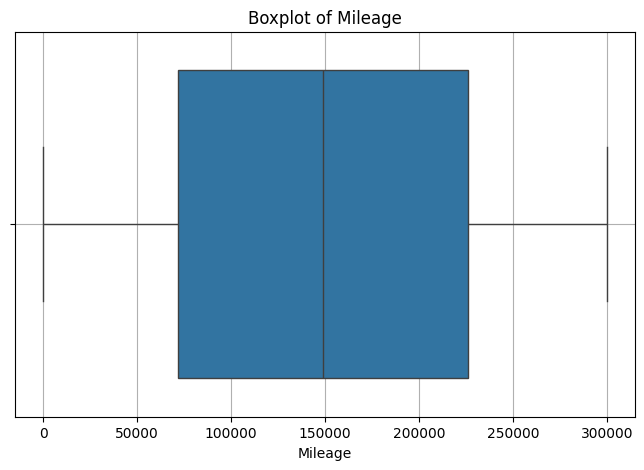

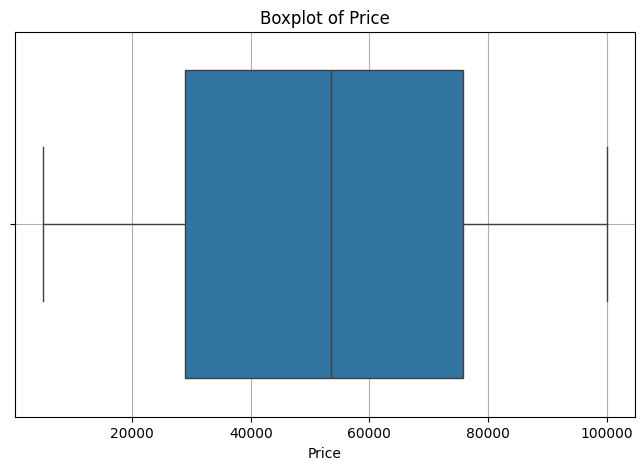

IQR Method for Outlier Detection:

Column "Year":
Bounds: [1985.50, 2037.50]
Number of outliers: 0

Column "Engine Size":
Bounds: [-1.55, 8.45]
Number of outliers: 0

Column "Mileage":
Bounds: [-159407.00, 457229.00]
Number of outliers: 0

Column "Price":
Bounds: [-41486.59, 146233.60]
Number of outliers: 0



In [3]:
numeric_columns = ['Year', 'Engine Size', 'Mileage', 'Price']

for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.grid(True)
    plt.show()

print('IQR Method for Outlier Detection:\n')
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'Column "{col}":')
    print(f'Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]')
    print(f'Number of outliers: {len(outliers)}\n')


Scaled Data:
        Year  Engine Size   Mileage     Price
0  0.625610    -0.813848 -0.397234 -0.953600
1  0.911720     0.652872 -0.074626 -1.390908
2  0.196444     0.722716  0.362347 -0.301770
3 -0.089667     0.443340 -0.922249  1.236198
4 -0.375778    -0.604316  0.833415  0.767270

Scaled Data Summary Statistics:

              Year   Engine Size       Mileage         Price
mean -4.188649e-16  5.487166e-16  9.379164e-17 -9.769963e-17
std   1.000200e+00  1.000200e+00  1.000200e+00  1.000200e+00
Gistogram for Scaled Data:



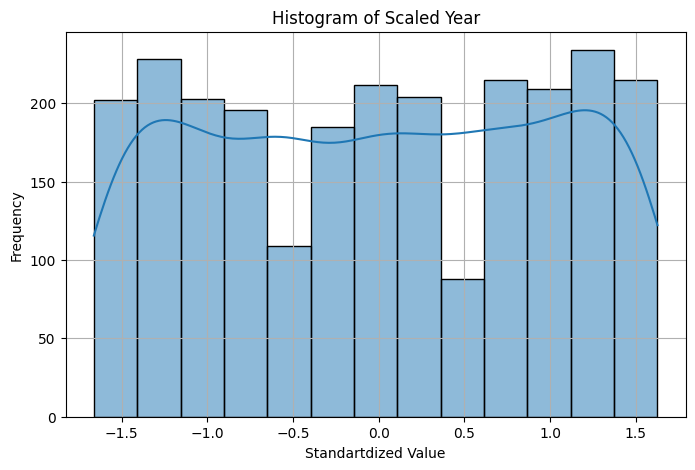

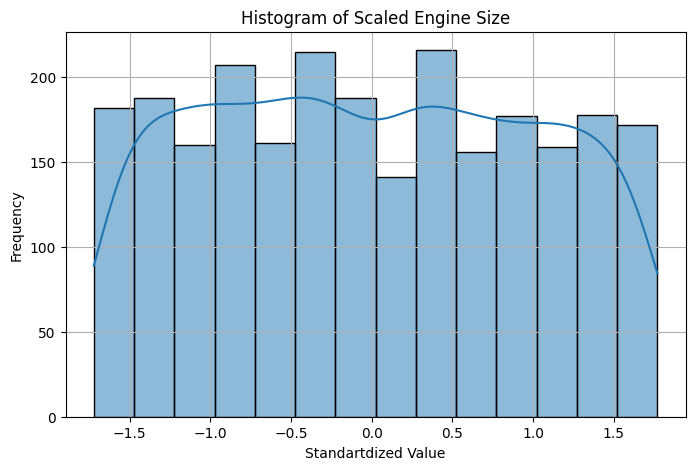

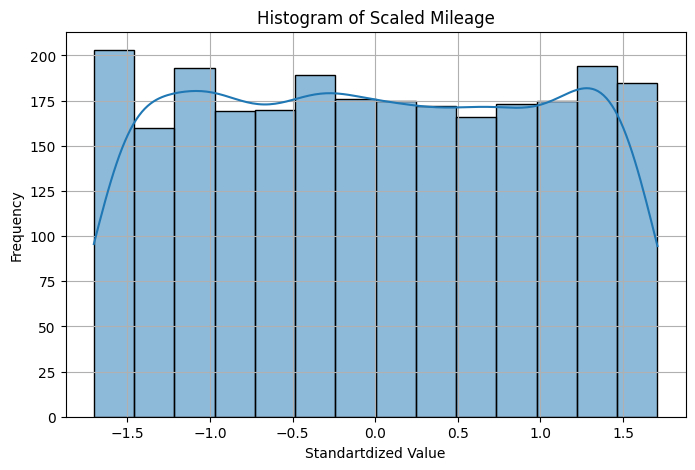

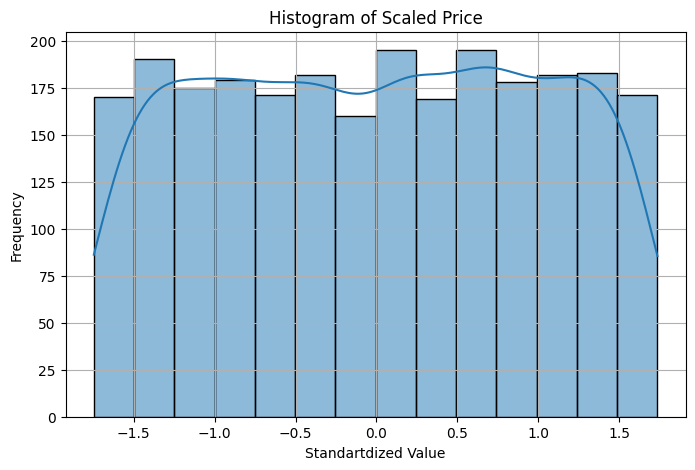


Results of statistical tests for normality:
 
Column: Year
Test Shapiro-Wilk: p-value = 3.4567143674646774e-29
Data does not follow normal distribution (reject H0)
Test D'Agostino-K2 (normaltest): p-value = 0.0
Data does not follow normal distribution (reject H0)

Column: Engine Size
Test Shapiro-Wilk: p-value = 8.377865491794019e-27
Data does not follow normal distribution (reject H0)
Test D'Agostino-K2 (normaltest): p-value = 0.0
Data does not follow normal distribution (reject H0)

Column: Mileage
Test Shapiro-Wilk: p-value = 4.765408651315983e-28
Data does not follow normal distribution (reject H0)
Test D'Agostino-K2 (normaltest): p-value = 0.0
Data does not follow normal distribution (reject H0)

Column: Price
Test Shapiro-Wilk: p-value = 2.7603104008409398e-27
Data does not follow normal distribution (reject H0)
Test D'Agostino-K2 (normaltest): p-value = 0.0
Data does not follow normal distribution (reject H0)



In [4]:
from scipy.stats import shapiro, normaltest
data_to_scale = df[numeric_columns].copy()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)
df_scaled = pd.DataFrame(scaled_data, columns=numeric_columns)
print("\nScaled Data:\n", df_scaled.head())
print("\nScaled Data Summary Statistics:\n")
print(df_scaled.describe().loc[['mean', 'std']])

print('Gistogram for Scaled Data:\n')
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_scaled[col], kde=True)
    plt.title(f'Histogram of Scaled {col}')
    plt.xlabel('Standartdized Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

print('\nResults of statistical tests for normality:\n ')
alpha = 0.05 
for col in df_scaled.columns:
    data_column = df_scaled[col]
    print(f'Column: {col}')
    stat_shapiro, p_shapiro = shapiro(data_column)
    print(f'Test Shapiro-Wilk: p-value = {p_shapiro}')
    if p_shapiro > alpha:
        print('Data follows normal distribution (fail to reject H0)')
    else:
        print('Data does not follow normal distribution (reject H0)')

    stat_k2, p_k2 = normaltest(data_column)
    print(f'Test D\'Agostino-K2 (normaltest): p-value = {p_k2}')
    if p_k2 > alpha:
        print('Data follows normal distribution (fail to reject H0)\n')
    else:
        print('Data does not follow normal distribution (reject H0)\n')


Correlation Matrix:
                  Year  Engine Size   Mileage     Price
Year         1.000000     0.011833  0.002282 -0.036805
Engine Size  0.011833     1.000000 -0.015782 -0.004420
Mileage      0.002282    -0.015782  1.000000 -0.008567
Price       -0.036805    -0.004420 -0.008567  1.000000


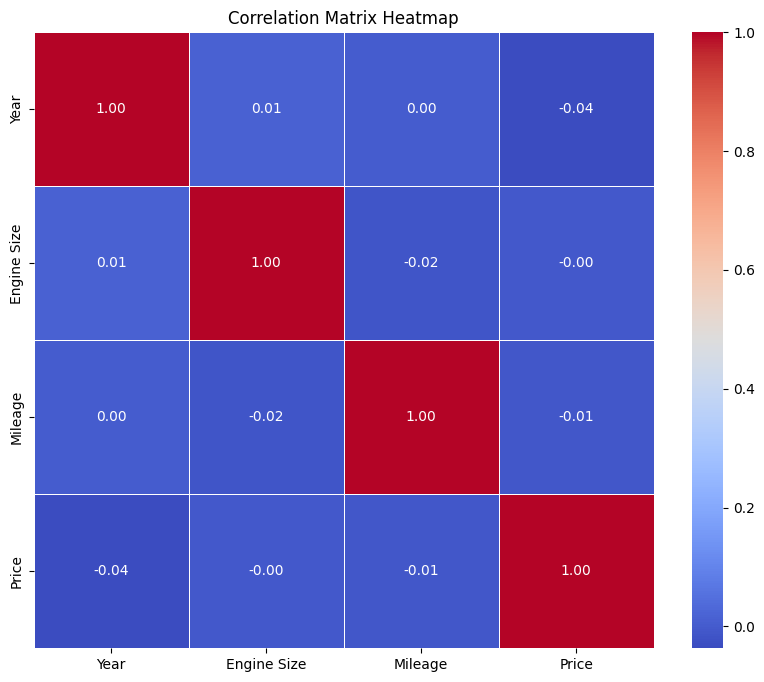

In [44]:
correlation_matrix = df[numeric_columns].corr()
print("\nCorrelation Matrix:\n", correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Результаты показали отсутствие значимых линейных корреляций между всеми исследуемыми признаками. Максимальный по модулю коэффициент корреляции (между 'Price' и 'Year') составил всего -0.04, что говорит о полном отсутствии линейной связи.
Вторая часть задания требовала провести анализ 'третьего фактора' для сильных корреляционных связей. Поскольку в данном наборе данных такие связи обнаружены не были, проведение такого анализа является нецелесообразным.